# 이미지 기반 RAG

In [1]:
from dotenv import load_dotenv
import os 
from langchain_openai import AzureChatOpenAI
from langchain_core.output_parsers import StrOutputParser

load_dotenv('env', override=True)
AZURE_OPENAI_API_KEY = os.getenv('AZURE_OPENAI_API_KEY')
END_POINT=os.getenv('END_POINT')
MODEL_NAME=os.getenv('MODEL_NAME')
print(AZURE_OPENAI_API_KEY[:10])
print(MODEL_NAME)

AZURE_OPENAI_EMB_API_KEY = os.getenv('AZURE_OPENAI_EMB_API_KEY')
EMB_END_POINT=os.getenv('EMB_END_POINT')
EMB_MODEL_NAME=os.getenv('EMB_MODEL_NAME')

MM_EMB_API_KEY=os.getenv('MM_EMB_API_KEY')
MM_EMB_ENDPOINT=os.getenv('MM_EMB_ENDPOINT')
MM_EMB_MODEL_NAME=os.getenv('MM_EMB_MODEL_NAME')

os.environ['LANGCHAIN_API_KEY'] = os.getenv('LANGSMITH_API_KEY')
os.environ['LANGCHAIN_ENDPOINT'] = os.getenv('LANGCHAIN_ENDPOINT')
os.environ['LANGCHAIN_TRACING_V2'] = 'true' #true, false
os.environ['LANGCHAIN_PROJECT'] = 'RAG'

if os.getenv('LANGCHAIN_TRACING_V2') == "true":
    print('랭스미스로 추적 중입니다 :', os.getenv('LANGSMITH_API_KEY')[:10])

43b13g4OZS
gpt-5-mini
랭스미스로 추적 중입니다 : lsv2_pt_24


In [ ]:
# %pip install azure-ai-inference

## OpenAI에 이미지 전송하기

이미지 파일을 api로 보내기 위해서는 이미지를 text형태로 변형해서 보내야합니다. 

base64는 바이너리 데이터를 문자열로 표현하는 인코딩 방법입니다.

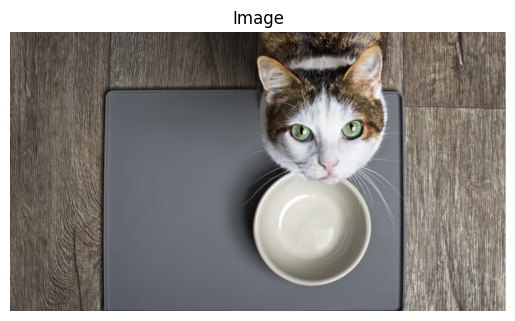

In [5]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("./img/cat1.jpg") 
plt.imshow(img)
plt.title("Image")
plt.axis("off")
plt.show()

In [6]:
llm = AzureChatOpenAI(
    api_key=AZURE_OPENAI_API_KEY,
    azure_endpoint=END_POINT,  
    azure_deployment=MODEL_NAME,     
    api_version="2024-12-01-preview",
    # temperature=0.1, # GPT5를 쓰는 경우 temp 삭제 
)

In [7]:
import base64, mimetypes, pathlib

def img_to_data_url(path: str) -> str:
    mime, _ = mimetypes.guess_type(path)
    if not mime:
        mime = "application/octet-stream"
    data = pathlib.Path(path).read_bytes()
    b64 = base64.b64encode(data).decode("utf-8")
    return f"data:{mime};base64,{b64}"



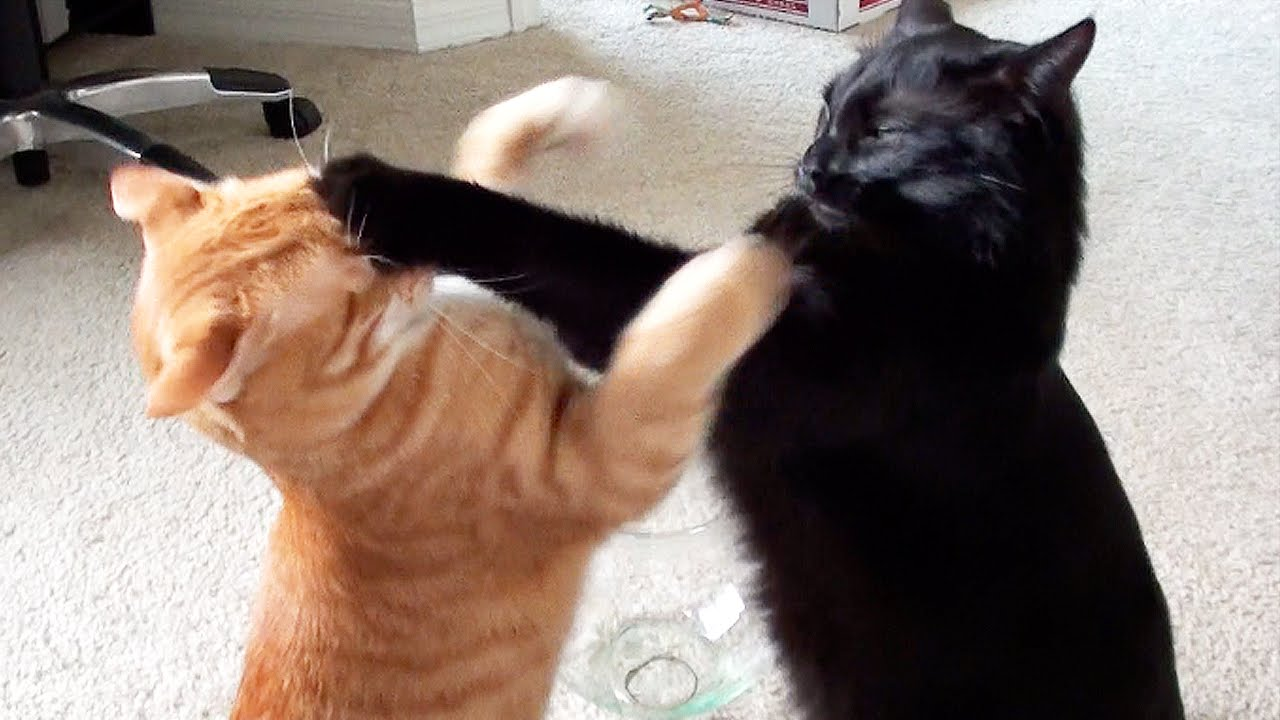

In [8]:
print(img_to_data_url('img/cat4.jpg'))

In [9]:
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_text_splitters import RecursiveCharacterTextSplitter

q = "이 사진에 대해서 설명해주세요."
msgs = [
    SystemMessage(content="너는 앞을 볼 수 없는 사람들에게 사진을 설명해주는 도우미다."),
    HumanMessage(content=[
        {"type": "text", "text": q},
        {"type": "image_url", "image_url": {"url": img_to_data_url("./img/cat1.jpg"), "detail": "auto"}},
                ])
]
resp = llm.invoke(msgs)
print(resp)

content='이 사진에는 갈색과 흰색이 섞인 털을 가진 고양이가 나와 있습니다. 고양이는 위에서 볼 때 정면을 바라보고 있으며, 초록색 눈이 돋보입니다. 고양이 앞에는 비어 있는 흰색 밥그릇이 놓여 있고, 그 밥그릇은 짙은 회색 매트 위에 올려져 있습니다. 바닥은 나무로 된 바닥재입니다. 고양이가 아마 밥을 기다리며 그릇을 바라보는 상황인 것 같습니다.' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 126, 'prompt_tokens': 596, 'total_tokens': 722, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_3dcd5944f5', 'id': 'chatcmpl-CSvVnFkzJwMCF4Us6fatXLI2qM4zx', 'service_tier': None, 'prompt_filter_results': [{'prompt_index': 1, 'content_filter_result': {'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}, 'hate': {'filtered': False, 'severity': 'safe'}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'custom_blocklists': {'

In [10]:
print(resp.content)

이 사진에는 갈색과 흰색이 섞인 털을 가진 고양이가 나와 있습니다. 고양이는 위에서 볼 때 정면을 바라보고 있으며, 초록색 눈이 돋보입니다. 고양이 앞에는 비어 있는 흰색 밥그릇이 놓여 있고, 그 밥그릇은 짙은 회색 매트 위에 올려져 있습니다. 바닥은 나무로 된 바닥재입니다. 고양이가 아마 밥을 기다리며 그릇을 바라보는 상황인 것 같습니다.


In [11]:
char_splitter = RecursiveCharacterTextSplitter(
    chunk_size=100,           
    chunk_overlap=20,         
)

for ch in char_splitter.split_text(resp.content):
    print(ch)

이 사진에는 갈색과 흰색이 섞인 털을 가진 고양이가 나와 있습니다. 고양이는 위에서 볼 때 정면을 바라보고 있으며, 초록색 눈이 돋보입니다. 고양이 앞에는 비어 있는 흰색 밥그릇이
앞에는 비어 있는 흰색 밥그릇이 놓여 있고, 그 밥그릇은 짙은 회색 매트 위에 올려져 있습니다. 바닥은 나무로 된 바닥재입니다. 고양이가 아마 밥을 기다리며 그릇을 바라보는
아마 밥을 기다리며 그릇을 바라보는 상황인 것 같습니다.


## 방법 1) 이미지를 캡션으로 변환하여 벡터 DB에 저장

In [12]:
# index_images_plain_caption.py
import os, glob, base64
from pathlib import Path
from typing import List
from dotenv import load_dotenv
from PIL import Image

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain.schema import Document
from langchain_core.messages import HumanMessage

INDEX_DIR = "vectorstores/animals_faiss"       # 인덱스 저장 위치
os.makedirs(INDEX_DIR, exist_ok=True)

In [13]:
from langchain_openai import AzureOpenAIEmbeddings

emb = AzureOpenAIEmbeddings(
    model=EMB_MODEL_NAME,                      
    api_key=AZURE_OPENAI_EMB_API_KEY,
    azure_endpoint=EMB_END_POINT,
    api_version="2024-08-01-preview"
)

PROMPT = (
    "너는 앞을 볼 수 없는 사람들에게 사진을 설명해주는 도우미다."
    "이미지의 장면을 한국어로 자연스럽게 3~5문장으로 상세히 서술하라. "
    "사진에 포함된 객체(동물, 사람, 물체), 상태/동작, 배경, 정서 등을 중심으로 문장으로 설명하라."
    "설명 만으로 이미지를 다시 구성할 수 있게 섬세하게 작성하라."
)

def caption_ko(path: str) -> str:
    msg = HumanMessage(content=[
        {"type": "text", "text": PROMPT},
        {"type": "image_url", "image_url": {"url": img_to_data_url(path)}}, #프롬프트에 이미지를 문자로 변경해서 전송
    ])
    resp = llm.invoke([msg]) #<--- gpt에서 프롬프트에 해당하는 방향으로 캡셔닝 생성요청
    return resp.content.strip()

# 이미지 파일 리스트 추출
def list_image_files(root: str) -> List[str]:
    exts = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
    files = [p for p in glob.glob(os.path.join(root, "**", "*.*"), recursive=True)
             if Path(p).suffix.lower() in exts]
    if not files:
        raise FileNotFoundError(f"No images found under: {root}")
    return sorted(files)

IMG_DIR = "img"     
from tqdm import tqdm

char_splitter = RecursiveCharacterTextSplitter(
    chunk_size=100,           
    chunk_overlap=20,         
)

def build_index():
    files = list_image_files(IMG_DIR) #이미지 파일 리스트 
    docs = []
    error_list = []
    for p in tqdm(files):
        try:
            cap = caption_ko(p)  
            metadata = {
                "path": os.path.abspath(p),
                "dir": str(Path(p).absolute().parent),
                "filename": Path(p).name,
                "caption_ko": cap,                              
            }

            chunks = char_splitter.split_text(cap)  # 캡션을 여러 조각으로
            
            # 인덱싱 텍스트는 순수 캡션만
            for ch in chunks:
                docs.append(Document(page_content=ch, metadata=metadata))
        except:
            error_list.append(p)

    vectordb = FAISS.from_documents(docs, embedding=emb)
    vectordb.save_local(INDEX_DIR)
    
    print(f"Indexed {len(docs)} images → {INDEX_DIR}")

    if error_list:
        print('다음 이미지를 변환하지 못했습니다.')
        print(error_list)
    
    return vectordb

vectordb =  build_index()

100%|██████████| 16/16 [00:58<00:00,  3.65s/it]


Indexed 53 images → vectorstores/animals_faiss


In [19]:
import pandas as pd

rows = []
for faiss_id, doc_id in sorted(vectordb.index_to_docstore_id.items()):
    doc = vectordb.docstore.search(doc_id)  
    md = doc.metadata or {}
    rows.append({
        "faiss_id": faiss_id,
        "filename": md.get("filename"),
        "dir": md.get("dir"),
        "path": md.get("path"),
        "caption_ko": doc.page_content[:80],
    })

df = pd.DataFrame(rows).sort_values("faiss_id").reset_index(drop=True)

print(f"vectors: {vectordb.index.ntotal}  |  dim: {vectordb.index.d}")

for idx in range(len(df)):
    row = df.iloc[idx]
    print(f"{row.faiss_id:4} | {row.filename:10}  | {row.caption_ko}")

vectors: 53  |  dim: 1536
   0 | bird.jpg    | 사진에는 짙은 검은색 깃털을 가진 큰 새 한 마리가 나무 가지 위에 조용히 앉아 있습니다. 이 새는 부리가 매우 크고 노란빛을 띠며, 부리 윗부
   1 | bird.jpg    | 독특한 주름 모양의 돌출된 구조가 있습니다. 새의 얼굴은 하얀색과 검은색이 뚜렷하게 대비되어 있으며, 눈 주변에는 파란색 고리 같은 무늬가 있습
   2 | bird.jpg    | 배경에는 초록색 야자수 잎과 나무 줄기가 흐릿하게 펼쳐져 있어 열대 우림이나 정글 같은 자연 환경임을 알 수 있습니다. 전체적으로 새는 고고하고
   3 | bird.jpg    | 침착한 분위기를 전달하며 자연 속에 완벽히 어우러져 있습니다.
   4 | bird2.jpg   | 이 사진에는 날개를 활짝 펴고 물 위를 낮게 날고 있는 흰머리독수리가 등장합니다. 독수리의 머리는 하얀 깃털로 뒤덮여 있고, 날카로운 노란 부리
   5 | bird2.jpg   | 부리와 강렬한 눈빛이 특징적입니다. 배경은 초록빛으로 물결치는 호수나 강으로 보이며, 반사된 나무들이 흐릿하게 비칩니다. 독수리는 집중한 표정으
   6 | bird2.jpg   | 목표를 향해 힘차게 날고 있는 모습입니다. 화면 오른쪽 아래에는 ‘NETFLIX’ 로고가 작게 표시되어 있습니다.
   7 | bird3.jpg   | 사진에는 가느다란 갈색 나뭇가지 위에 다섯 마리의 작은 참새들이 옹기종기 모여 앉아 있습니다. 이 새들은 모두 몸길이가 작고 둥글며, 주로 회색
   8 | bird3.jpg   | 흰색 깃털을 가지고 있고, 부리는 오렌지색과 빨간색으로 뚜렷하게 대비됩니다. 새들 중 세 마리는 얼룩무늬가 있고, 특히 얼굴 양쪽에 오렌지색 반
   9 | bird3.jpg   | 반점이 뚜렷한데, 이는 특징적인 무늬입니다. 나무 가지는 잎이 없고 배경은 흐릿하게 처리되어 있어 새들이 더욱 선명하게 돋보이며, 전체적으로 평
  10 | bird3.jpg 

쿼리 문장 	: 따뜻함
검색된 문장 	: 이들이 함께 있어 따뜻하고 안정된 느낌을 자아냅니다.
/Users/kb/Desktop/AI/llm_langchain_langraph/RAG/RAG_multimodal/img/dog1.jpg


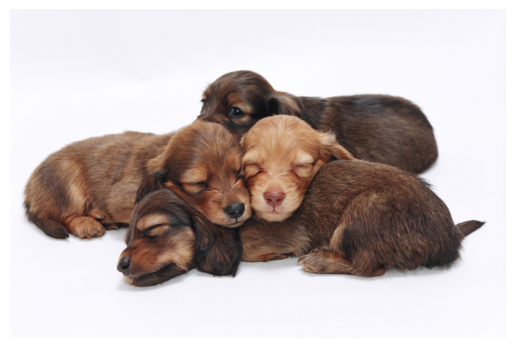

In [16]:
import os
from typing import Optional
from dotenv import load_dotenv
from langchain_community.vectorstores import FAISS
from matplotlib import pyplot as plt
from PIL import Image

INDEX_DIR = "vectorstores/animals_faiss"

def load_store() -> FAISS:
    return FAISS.load_local(INDEX_DIR, embeddings=emb, allow_dangerous_deserialization=True)

def search_directory(query_ko: str, k: int = 4) -> Optional[str]:
    store = load_store()
    docs = store.similarity_search(query_ko, k=k)
    if not docs:
        return None
    top = docs[0]
    return top


q = "따뜻함"
result = search_directory(q)

print(f'쿼리 문장 \t: {q}')
print(f'검색된 문장 \t: {result.page_content[:80]}')
print(result.metadata.get("path"))  # 가장 유사한 이미지의 파일 경로

img_path = result.metadata.get("path")
if img_path and os.path.exists(img_path):
    img = Image.open(img_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

## 방법 2) 이미지를 그대로 임베딩하기 -  멀티모달 임베딩 (CLIP)

In [21]:
from azure.ai.inference import ImageEmbeddingsClient
from azure.core.credentials import AzureKeyCredential
img_client = ImageEmbeddingsClient(
    endpoint=MM_EMB_ENDPOINT,
    credential=AzureKeyCredential(MM_EMB_API_KEY),
)

from azure.ai.inference.models import ImageEmbeddingInput
img_input = ImageEmbeddingInput.load(image_file="img/cat1.jpg", image_format="jpg")
res = img_client.embed(input=[img_input], model='embed-v-4-0')

# 이미지가 1536차원 벡터(list)로 임베딩되었습니다.
print(res.data[0].embedding[:10])
print(type(res.data[0].embedding))
print(len(res.data[0].embedding))

[0.020629883, 0.045166016, -0.014221191, -0.022583008, 0.016113281, -0.01171875, 0.037597656, -0.003967285, 0.0051574707, 0.017822266]
<class 'list'>
1536


In [22]:
from azure.ai.inference.models import ImageEmbeddingInput
img_input = ImageEmbeddingInput.load(image_file="img/cat1.jpg", image_format="jpg")
res = img_client.embed(input=[img_input], model='embed-v-4-0')

# 이미지가 1536차원 벡터(list)로 임베딩되었습니다.
print(res.data[0].embedding[:10])
print(type(res.data[0].embedding))
print(len(res.data[0].embedding))

[0.020629883, 0.045166016, -0.014221191, -0.022583008, 0.016113281, -0.01171875, 0.037597656, -0.003967285, 0.0051574707, 0.017822266]
<class 'list'>
1536


In [23]:
from azure.ai.inference import EmbeddingsClient
text_client = EmbeddingsClient(
    endpoint=MM_EMB_ENDPOINT,
    credential=AzureKeyCredential(MM_EMB_API_KEY),
)

res = text_client.embed(input=['아 배가 고프다'], model='embed-v-4-0')

# 마찬가지로 텍스트도 1536차원 벡터(list)로 임베딩되었습니다.
print(res.data[0].embedding[:10])
print(type(res.data[0].embedding))
print(len(res.data[0].embedding))

[0.020385742, -0.016967773, 0.014038086, -0.0034179688, 0.020507812, 0.0021820068, -0.007019043, -0.012268066, 0.025512695, -0.020019531]
<class 'list'>
1536


In [24]:
import numpy as np
from typing import List

def embed_image(path: str, image_format: str = "jpg") -> list:
    img_input = ImageEmbeddingInput.load(image_file=path, image_format=image_format)
    res = img_client.embed(input=[img_input], model=MM_EMB_MODEL_NAME)
    return np.array(res.data[0].embedding)

def embed_images(paths: List[str], image_format: str = "jpg") -> list:
    image_inputs = [ImageEmbeddingInput.load(image_file=image_file, image_format=image_format) for image_file in paths]

    res = img_client.embed(input=image_inputs, model=MM_EMB_MODEL_NAME)
    return np.array([res.data[i].embedding for i in range(len(res.data))])

def embed_text(text: str) -> list:
    return np.array(text_client.embed(input=[text], model=MM_EMB_MODEL_NAME).data[0].embedding)

def embed_texts(texts: List[str]) -> list:
    res = text_client.embed(input=texts, model=MM_EMB_MODEL_NAME)
    return np.array([r.embedding for r in res.data])

In [25]:
txts = ["Three cheerful puppies smiling together in the sunshine", 
        "A family of elephants walking peacefully across the African savanna", 
        "A panda enjoying bamboo in a calm green forest",
        "The morning sky was painted with shades of orange and pink",
        "A cute cat is playing with a ball",
        "Children are playing soccer on a sunny afternoon",
        "A computer is on the table. a man is typing on it"]

In [27]:
from typing import List
import glob
import os
from pathlib import Path

def list_image_files(root: str) -> List[str]:
    exts = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
    files = [p for p in glob.glob(os.path.join(root, "**", "*.*"), recursive=True)
             if Path(p).suffix.lower() in exts]
    return sorted(files)

IMG_DIR = "img"     

image_files = list_image_files(IMG_DIR)
print(len(image_files), image_files[:5])

16 ['img/bird.jpg', 'img/bird2.jpg', 'img/bird3.jpg', 'img/cat1.jpg', 'img/cat2.jpg']


이미지와 텍스트를 만든 임베딩 함수를 사용해 모두 임베딩해 보겠습니다.

In [28]:
img_embeddings = embed_images(image_files)
text_embeddings = embed_texts(txts)

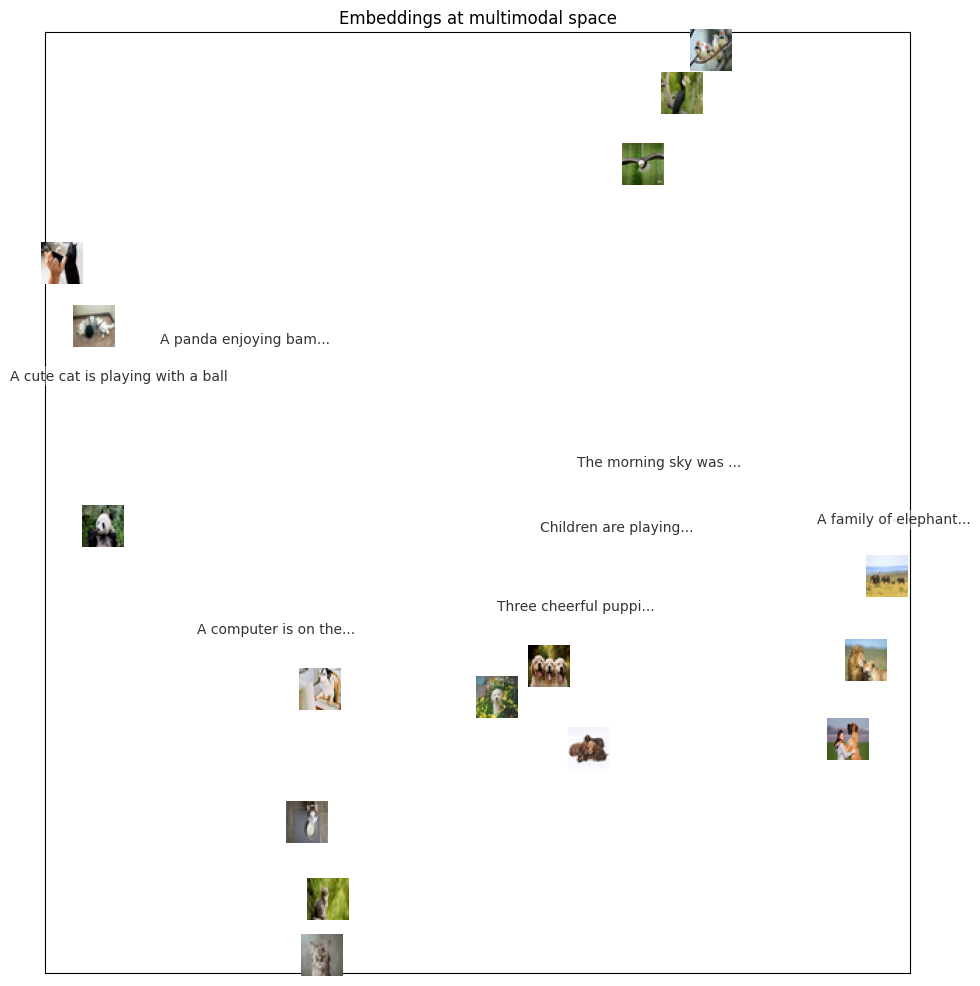

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
from typing import List, Optional, Tuple
from sklearn.manifold import TSNE

def _to_fixed_thumbnail(arr: np.ndarray, size: Tuple[int, int]) -> np.ndarray:
    img_pil = Image.fromarray(arr)
    resized = img_pil.resize(size, Image.Resampling.LANCZOS)
    return np.array(resized)

def visualize_tsne_multimodal(
    image_embeddings: np.ndarray,            
    images: List[np.ndarray],
    text_embeddings: Optional[np.ndarray] = None,  
    texts: Optional[List[str]] = None,            

    learning_rate = "auto",
    thumb_size = 30,
    text_fontsize = 10,
    text_alpha = 0.8,
    text_box = True,
    figsize = (10, 10),
):

    tsne = TSNE(
        n_components=2,
        perplexity=2,
        learning_rate=learning_rate,
        random_state=42,
        init="pca",
    )
    
    combined = np.vstack([image_embeddings, text_embeddings])
    emb2 = tsne.fit_transform(combined)

    n_img = image_embeddings.shape[0]
    x, y = emb2[:, 0], emb2[:, 1]
    x = (x - x.min()) / (x.max() - x.min() + 1e-9)
    y = (y - y.min()) / (y.max() - y.min() + 1e-9)
    img_xy = np.c_[x[:n_img], y[:n_img]]
    txt_xy = np.c_[x[n_img:], y[n_img:]] 
    
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title('Embeddings at multimodal space')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)

    fixed = (thumb_size, thumb_size)
    for (px, py), arr in zip(img_xy, images):
        thumb = _to_fixed_thumbnail(arr, fixed)
        imagebox = OffsetImage(thumb, resample=True)
        ab = AnnotationBbox(imagebox, (px, py), frameon=False, pad=0.0)
        ax.add_artist(ab)

    ax.scatter(txt_xy[:, 0], txt_xy[:, 1], s=4, alpha=0.12)
    for (px, py), t in zip(txt_xy, texts):
        label = t if len(t) <= 40 else (t[:20] + "...")
        bbox = dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.4) if text_box else None
        ax.text(px, py, label,
                ha="center", va="center",
                fontsize=text_fontsize,
                alpha=text_alpha,
                bbox=bbox)

    plt.tight_layout()
    plt.show()

images = [plt.imread(p) for p in image_files]

visualize_tsne_multimodal(
    image_embeddings=img_embeddings,
    images=images,
    text_embeddings=text_embeddings,
    texts=txts,
    figsize=(10, 10),
)

In [ ]:
import faiss

INDEX_DIR = "vectorstores/faiss"
os.makedirs(INDEX_DIR, exist_ok=True)

# 코사인 유사도 = inner product 
index = faiss.IndexFlatIP(len(img_embeddings[0])) #전체 벡터를 내적으로 유사도 비교. 임베딩 차원의 크기를 넣어주면 됨
index.add(img_embeddings)
faiss.write_index(index, os.path.join(INDEX_DIR, "index.faiss")) 
#이미지 임베딩은 비용이 많이 들어가므로 한번 임베딩할 때 저장하는 것이 좋습니다.

import json
with open(os.path.join(INDEX_DIR, "meta.json"), "w", encoding="utf-8") as f:
    json.dump(image_files, f, ensure_ascii=False, indent=2)

print(f"{len(image_files)}개 이미지를 {INDEX_DIR}에 저장")

16개 이미지를 vectorstores/faiss에 저장


In [ ]:
# 불러올 때
# 파일 이미 생성된 경우 
index = faiss.read_index(os.path.join(INDEX_DIR, "index.faiss"))
with open(os.path.join(INDEX_DIR, "meta.json"), "r", encoding="utf-8") as f:
    paths = json.load(f) 

In [35]:
# 텍스트로 이미지 검색
def search_by_text(query: str, k: int = 5):
    q = embed_text(query)  # 앞에 새로운 차원을 추가하고 뒤에 차원은 그대로 유지
    np_q = np.array(q, dtype=np.float32).reshape(1, -1)
    sims, idxs = index.search(np_q, k)  
    return [(paths[i], float(s)) for i, s in zip(idxs[0], sims[0])]

# 이미지로 이미지 검색
def search_by_image(img_path: str, k: int = 5, image_format: str = "jpg"):
    q = embed_image(img_path, image_format)
    np_q = np.array(q, dtype=np.float32).reshape(1, -1)
    sims, idxs = index.search(np_q, k)
    return [(paths[i], float(s)) for i, s in zip(idxs[0], sims[0])]

유사도 : 0.345  파일 : img/dog2.jpg


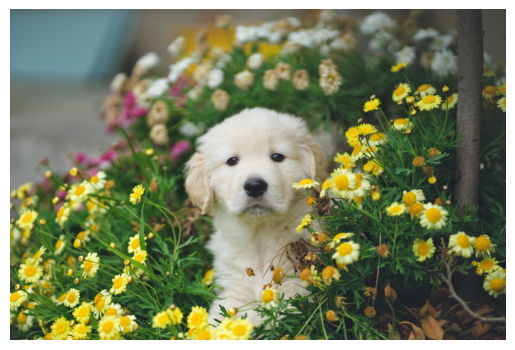

유사도 : 0.336  파일 : img/dog4.jpg


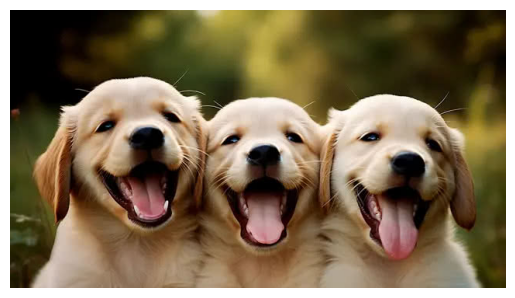

유사도 : 0.313  파일 : img/dog3.jpg


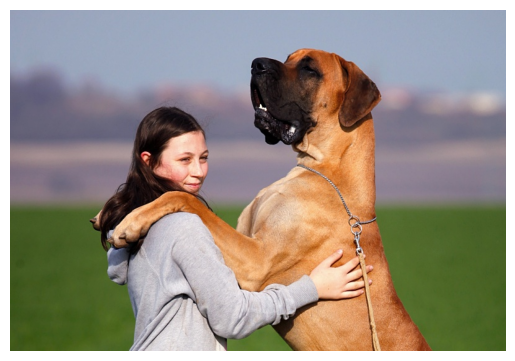

In [36]:
from matplotlib import pyplot as plt
from PIL import Image

results = search_by_text("강아지", k=3)

for p, s in results:
    print(f"유사도 : {s:.3f}  파일 : {p}")
    img = Image.open(p)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

유사도 : 0.404  파일 : img/cat2.jpg


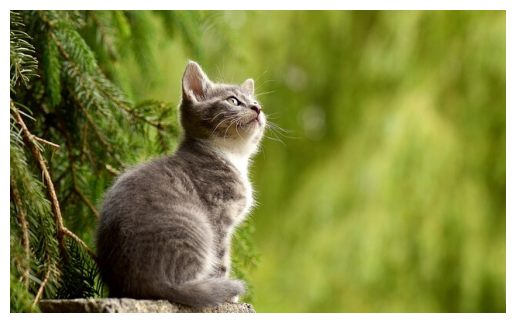

유사도 : 0.369  파일 : img/cat4.jpg


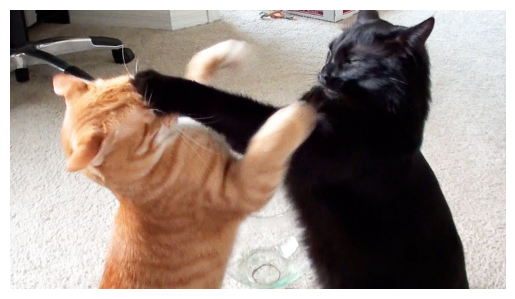

유사도 : 0.364  파일 : img/cat1.jpg


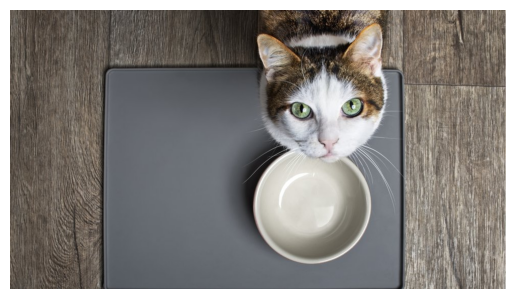

In [37]:
results = search_by_text("cute cats", k=3)

for p, s in results:
    print(f"유사도 : {s:.3f}  파일 : {p}")
    img = Image.open(p)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

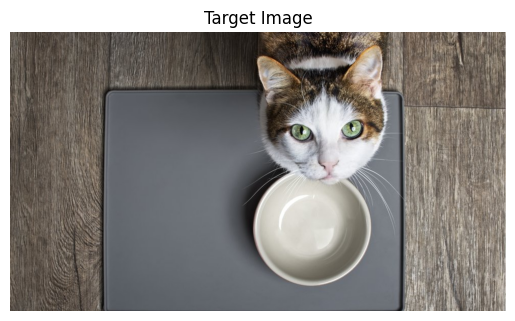

유사도 : 1.000  파일 : img/cat1.jpg


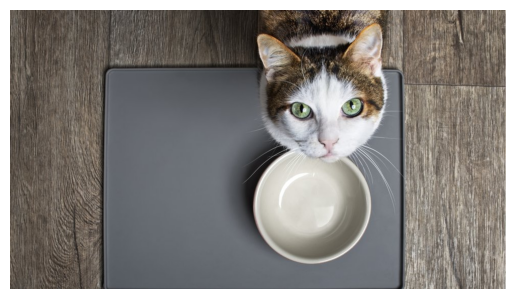

유사도 : 0.408  파일 : img/cat2.jpg


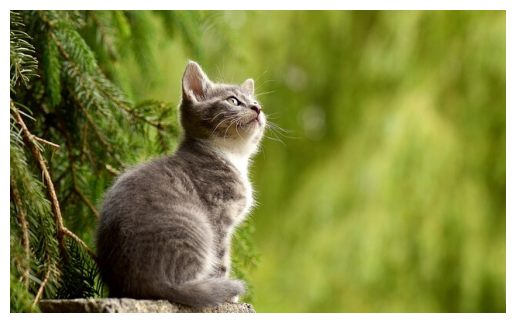

유사도 : 0.386  파일 : img/cat5.jpg


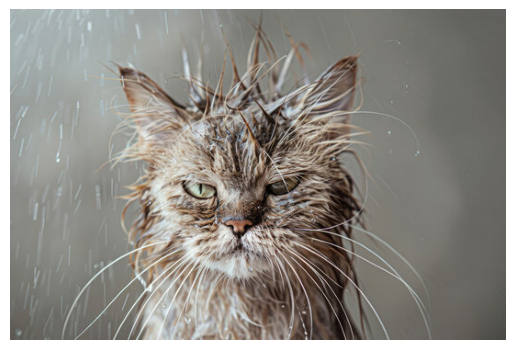

유사도 : 0.336  파일 : img/dog5.jpg


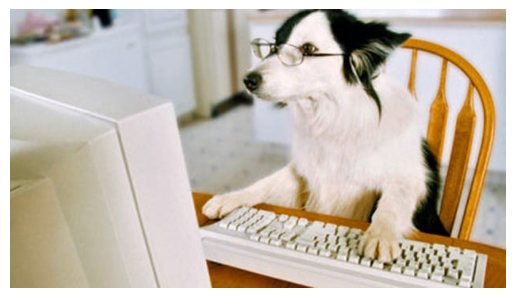

유사도 : 0.313  파일 : img/cat4.jpg


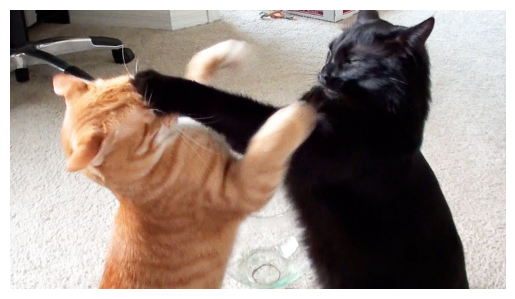

In [38]:
q_img = 'img/cat1.jpg'

img = Image.open(q_img)
plt.imshow(img)
plt.title('Target Image')
plt.axis('off')
plt.show()

for p, s in search_by_image(q_img, image_format=q_img.split('.')[-1]):
    print(f"유사도 : {s:.3f}  파일 : {p}")
    img = Image.open(p)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

## 이미지를 이해하는 대화형 Agentic RAG 만들기

In [39]:
from pathlib import Path
from typing import List, Dict, Any
from pydantic import BaseModel, Field

from langchain_openai import AzureChatOpenAI
from langchain_core.tools import tool
from langchain.tools import StructuredTool
from langchain.agents import AgentExecutor, create_tool_calling_agent
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_core.runnables.history import RunnableWithMessageHistory
from langchain_community.chat_message_histories import ChatMessageHistory

In [ ]:
# 이미지 파일을 base64로 인코딩하여 data URL 형식으로 변환하는 함수
# LLM에 이미지를 전달할 때 필요 (OpenAI API는 이미지를 data URL 형식으로 받음)
import base64, mimetypes, pathlib

def img_to_data_url(path: str) -> str:
    mime, _ = mimetypes.guess_type(path)
    if not mime:
        mime = "application/octet-stream"
    data = pathlib.Path(path).read_bytes()
    b64 = base64.b64encode(data).decode("utf-8")
    return f"data:{mime};base64,{b64}"

In [ ]:
class SearchTextInput(BaseModel): #함수에 들어갈 변수의 설명 -> LLM이 읽을 수 있게 
    query: str = Field(..., description="이미지를 찾을 영어 질의")

@tool("search_images_by_text", args_schema=SearchTextInput)
def search_images_by_text_tool(query: str) -> Dict[str, Any]:
    """입력된 텍스트로 가장 유사한 이미지를 검색하고, 경로/파일명/점수를 반환한다.""" # 툴 자체에 대한 설명 
    
    hits = search_by_text(query)
    results = [
        {"rank": i+1, "path": p, "filename": Path(p).name, "score": float(s)}
        for i, (p, s) in enumerate(hits)
    ]
    
    # 에이전트가 이어서 사용할 수 있도록 구조화해서 반환
    return {"query": query, "results": results}

In [ ]:
class SearchImageInput(BaseModel):
    image_path: str = Field(..., description="로컬 이미지 경로")

@tool("search_images_by_image", args_schema=SearchImageInput)
def search_images_by_image_tool(image_path: StopIteration) -> Dict[str, Any]:
    """이미지로 파일경로 내의 다른 유사 이미지를 검색한다. 유사도가 1인 경우는 입력과 동일한 사진이다."""
    
    hits = search_by_image(image_path)
    results = [
        {"rank": i+1, "path": p, "filename": Path(p).name, "score": float(s)}
        for i, (p, s) in enumerate(hits)
    ]
    return {"image_path": image_path, "results": results}

In [44]:
class DescribeInput(BaseModel):
    image_path: str = Field(..., description="설명이 필요한 이미지의 로컬 경로")
    
@tool("describe_image", args_schema=DescribeInput)
def describe_image_tool(image_path: str) -> Dict[str, Any]:
    """로컬 이미지 파일의 경로를 data URL로 첨부하여 gpt에게서 자세한 이미지의 설명을 텍스트로 받아 반환한다."""
    if not Path(image_path).exists():
        return {"error": f"file not found: {image_path}"}

    sys = SystemMessage(content=(
        "너는 시각 보조 도우미다. 제공된 이미지를 보고 한국어로 4~6문장으로 설명하라. "
        "객체/배경/구도/색감/분위기/활동을 포함하고, 마지막에 간단한 태그 3~5개를 붙여라."
    ))

    human = HumanMessage(content=[
        {"type": "text", "text": "이 이미지를 자연스럽고 구체적으로 설명해줘."},
        {"type": "image_url", "image_url": {"url": img_to_data_url(image_path), "detail": "high"}}
    ])
    out = (llm | StrOutputParser()).invoke([sys, human])
    return {"image_path": image_path, "description": out}


In [45]:
TOOLS: List[StructuredTool] = [
    search_images_by_text_tool,
    search_images_by_image_tool,
    describe_image_tool,
]

In [46]:
SYSTEM = """너는 이미지 검색/설명 워크플로를 돕는 도우미다.
도구를 적극적으로 사용해서 사용자의 요청을 해결하라.
원칙:
- 한국어로 답하라.
- 결과를 보여줄 때는 번호와 파일명을 함께 나열하라.
- 텍스트로 이미지를 검색할 때 사용자의 질문을 이미지 검색에 적합한 영어 문장으로 변환하라.
- 이미지의 파일 이름을 출력할 때에는 파일 경로를 포함해서 출력하라.
- 이미지로 이미지를 검색할 때에는 파일의 경로를 확실하게 확인해라.
- 이미지로 검색한 결과의 유사도가 1이면 입력과 동일한 이미지이므로 검색 결과에서 제외하라.
- 사용자가 '그 이미지'처럼 지시하면, 직전 검색 결과에서 가장 적합한 항목을 선택하거나 번호를 확인 질문하라.
- 설명이 필요하면 describe_image 도구를 호출해 이미지(data URL)를 LLM으로 보내라.
- 모호하면 간단히 되묻고, 필요한 경우 재검색(tool) 하라.
- 여러개의 검색 결과를 모두 보여줄 필요가 없다면 가장 적합한 결과를 하나 선택해 보여줘라.

도구 리스트:
- search_images_by_text: 텍스트로 이미지 검색
- search_images_by_image: 이미지로 이미지 검색
- describe_image: 이미지 설명
"""

llm = AzureChatOpenAI(
    api_key=AZURE_OPENAI_API_KEY,
    azure_endpoint=END_POINT,  
    azure_deployment=MODEL_NAME,          
    api_version="2024-12-01-preview",
)

prompt = ChatPromptTemplate.from_messages([
    SystemMessage(content=SYSTEM),
    MessagesPlaceholder("chat_history"),
    MessagesPlaceholder('agent_scratchpad'),
    ("human", "{input}")
])

agent = create_tool_calling_agent(llm, TOOLS, prompt)
agent_executor = AgentExecutor(agent=agent, tools=TOOLS, verbose=True)

In [47]:
_store: Dict[str, ChatMessageHistory] = {}
def get_history(sid: str) -> ChatMessageHistory:
    if sid not in _store:
        _store[sid] = ChatMessageHistory()
    return _store[sid]

app = RunnableWithMessageHistory(
    agent_executor,
    get_session_history=get_history,
    history_messages_key="chat_history",
    input_messages_key="input",
    output_messages_key="output",
)

In [48]:
def chat(sid: str, user_text: str) -> str:
    cfg = {"configurable": {"session_id": sid}}
    return app.invoke({"input": user_text}, config=cfg)["output"]

sid = "u1"
print(chat(sid, "꽃 속에 있는 강아지 사진 있어? 찾아줘."))



> Entering new AgentExecutor chain...

Invoking: `search_images_by_text` with `{'query': 'dog in flowers'}`


{'query': 'dog in flowers', 'results': [{'rank': 1, 'path': 'img/dog2.jpg', 'filename': 'dog2.jpg', 'score': 0.5353221893310547}, {'rank': 2, 'path': 'img/dog5.jpg', 'filename': 'dog5.jpg', 'score': 0.2746214270591736}, {'rank': 3, 'path': 'img/dog4.jpg', 'filename': 'dog4.jpg', 'score': 0.2738763689994812}, {'rank': 4, 'path': 'img/cat5.jpg', 'filename': 'cat5.jpg', 'score': 0.2240927517414093}, {'rank': 5, 'path': 'img/dog3.jpg', 'filename': 'dog3.jpg', 'score': 0.2109908014535904}]}꽃 속에 있는 강아지 사진으로 다음 이미지들을 찾았습니다.

1. img/dog2.jpg
2. img/dog5.jpg
3. img/dog4.jpg
4. img/dog3.jpg

필요하면 특정 번호 알려주세요.

> Finished chain.
꽃 속에 있는 강아지 사진으로 다음 이미지들을 찾았습니다.

1. img/dog2.jpg
2. img/dog5.jpg
3. img/dog4.jpg
4. img/dog3.jpg

필요하면 특정 번호 알려주세요.


In [49]:
print(chat(sid, "가장 관련있는 이미지를 자세하게 설명해줘"))



> Entering new AgentExecutor chain...

Invoking: `search_images_by_text` with `{'query': 'dog in flowers'}`


{'query': 'dog in flowers', 'results': [{'rank': 1, 'path': 'img/dog2.jpg', 'filename': 'dog2.jpg', 'score': 0.5353221893310547}, {'rank': 2, 'path': 'img/dog5.jpg', 'filename': 'dog5.jpg', 'score': 0.2746214270591736}, {'rank': 3, 'path': 'img/dog4.jpg', 'filename': 'dog4.jpg', 'score': 0.2738763689994812}, {'rank': 4, 'path': 'img/cat5.jpg', 'filename': 'cat5.jpg', 'score': 0.2240927517414093}, {'rank': 5, 'path': 'img/dog3.jpg', 'filename': 'dog3.jpg', 'score': 0.2109908014535904}]}
Invoking: `describe_image` with `{'image_path': 'img/dog2.jpg'}`


{'image_path': 'img/dog2.jpg', 'description': '이 사진에는 노란색 꽃들 사이에 자리 잡은 흰색 강아지가 중심에 있습니다. 강아지는 부드러운 털을 가지고 있으며, 다소 차분한 표정을 짓고 있습니다. 배경에는 다양한 꽃들이 어우러져 있어 전체적으로 자연 친화적인 느낌을 주고 있습니다. 사진은 앞쪽 꽃들과 강아지를 선명하게 포커스를 맞춰 조화로운 구도를 만들어냈습니다. 따뜻하고 포근한 색감이 사진 전체에 생기와 평화를 전달하는 분위기를 연출합니다. 강아지가 꽃들 사이에서 조용히 쉬고 있는 듯한 여유로운 순간을 담고 있습니다.  \n#강아지 #노란꽃 #자

In [50]:
print(chat(sid, "그 사진과 비슷한 사진을 모두 찾아줘"))



> Entering new AgentExecutor chain...

Invoking: `search_images_by_image` with `{'image_path': 'img/dog2.jpg'}`


{'image_path': 'img/dog2.jpg', 'results': [{'rank': 1, 'path': 'img/dog2.jpg', 'filename': 'dog2.jpg', 'score': 1.0006619691848755}, {'rank': 2, 'path': 'img/dog4.jpg', 'filename': 'dog4.jpg', 'score': 0.5495505332946777}, {'rank': 3, 'path': 'img/cat2.jpg', 'filename': 'cat2.jpg', 'score': 0.4143405556678772}, {'rank': 4, 'path': 'img/dog1.jpg', 'filename': 'dog1.jpg', 'score': 0.36271995306015015}, {'rank': 5, 'path': 'img/panda.jpg', 'filename': 'panda.jpg', 'score': 0.3420027792453766}]}img/dog2.jpg 사진과 비슷한 사진들을 찾았습니다. 유사도 순서대로 나열하면 다음과 같습니다.

1. img/dog4.jpg (유사도 0.55)
2. img/cat2.jpg (유사도 0.41)
3. img/dog1.jpg (유사도 0.36)
4. img/panda.jpg (유사도 0.34)

필요한 사진 번호를 알려주시면 더 자세히 설명하거나 보여드릴 수 있습니다.

> Finished chain.
img/dog2.jpg 사진과 비슷한 사진들을 찾았습니다. 유사도 순서대로 나열하면 다음과 같습니다.

1. img/dog4.jpg (유사도 0.55)
2. img/cat2.jpg (유사도 0.41)
3. img/dog1.jpg (유사도 0.36)
4. img/panda.jpg (유사

In [51]:
sid = "u2"
print(chat(sid, "데이터 중에서 새에 관련된된 이미지를 모두 검색해서 찾아주고 모든 사진에 대해서 어떤 이미지인지 간단하게 설명해줘."))



> Entering new AgentExecutor chain...

Invoking: `search_images_by_text` with `{'query': 'birds'}`


{'query': 'birds', 'results': [{'rank': 1, 'path': 'img/bird3.jpg', 'filename': 'bird3.jpg', 'score': 0.3999477028846741}, {'rank': 2, 'path': 'img/bird2.jpg', 'filename': 'bird2.jpg', 'score': 0.3451751470565796}, {'rank': 3, 'path': 'img/bird.jpg', 'filename': 'bird.jpg', 'score': 0.28976452350616455}, {'rank': 4, 'path': 'img/dog4.jpg', 'filename': 'dog4.jpg', 'score': 0.28887179493904114}, {'rank': 5, 'path': 'img/cat2.jpg', 'filename': 'cat2.jpg', 'score': 0.2692059874534607}]}
Invoking: `describe_image` with `{'image_path': 'img/bird3.jpg'}`


{'image_path': 'img/bird3.jpg', 'description': '사진에는 다섯 마리의 작은 새들이 가지에 나란히 앉아 있는 모습이 담겨 있다. 이 새들은 주로 흰색과 회색, 갈색, 주황색 부리를 가지고 있으며, 어떤 새들은 얼굴과 가슴 부분에 줄무늬가 보인다. 새들은 모두 서로 바짝 붙어 있어 친근한 분위기가 느껴지고, 배경은 부드럽게 흐려져 새들이 돋보인다. 전체적인 색감은 자연스럽고 부드러운 톤으로 차분한 느낌을 준다. 이 장면은 새들이 휴식하며 서로의 존재를 느끼는 평화로운 순간을 잘 포착하고 있다. \n\n#새 #자연 #동물 #평화로운풍경 #가지걸이'}
Invoking: `d

마지막 결과를 보면 이미지의 설명은 잘 되어 있지만 그것을 요약할 때 문제가 생기는 것을 알 수 있습니다.

--> 요약기를 도구로 추가하여 이미지에 대한 간단한 설명 과정에서 문제가 없게 수정해보세요.